In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import pickle

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
!pip install contractions -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.0 MB/s eta 0:00:00


In [3]:
file_path = '/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv' 
df = pd.read_csv(file_path, encoding='latin-1')

# Membuang kolom ekstra yang isinya 99% null (Unnamed: 2, Unnamed: 3, Unnamed: 4)
df = df[['v1', 'v2']]

# Mengubah nama kolom agar sesuai dengan kodinganmu sebelumnya
df.columns = ['label', 'text_']

print(f"Jumlah pesan: {len(df):,}")
print(f"Jumlah kolom: {df.shape[1]}")
print()
print(f"Kolom yang tersedia:\n{list(df.columns)}")

Jumlah pesan: 5,572
Jumlah kolom: 2

Kolom yang tersedia:
['label', 'text_']


In [4]:
df.head()

,label,text_
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text_   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.dtypes

label    object
text_    object
dtype: object

In [7]:
df.isnull().sum()

label    0
text_    0
dtype: int64

In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
label    0
text_    0
dtype: int64


In [9]:
print("Distribusi Label:")
print(df['label'].value_counts())

Distribusi Label:
label
ham     4825
spam     747
Name: count, dtype: int64


In [10]:
import string
import re
import contractions
from nltk.tokenize import word_tokenize

# en_stopwords = set(stopwords.words('english'))
punctuation = set(string.punctuation)

def preprocessing(statement):
    # 1. Lowercasing
    statement = statement.lower()
    # 2. Contraction handling (don't -> do not, can't -> cannot)
    statement = contractions.fix(statement)
    # 3. Hapus punctuation 
    statement = re.sub(r'[^\w\s]', '', statement)
    # 4. Hapus angka 
    statement = re.sub(r'\d+', '', statement)
    # 5. Tokenisasi
    tokens = word_tokenize(statement)
    # 6. Hanya huruf (hapus angka sisa)
    tokens = [token for token in tokens if token.isalpha()]
    # 7. Hapus kata yang terlalu pendek (1-2 karakter)
    tokens = [token for token in tokens if len(token) > 2]
    
    return ' '.join(tokens)

df['clean_text'] = df['text_'].apply(preprocessing)

print("Contoh hasil:")
print("\nOriginal:", df['text_'].iloc[0])
print("Clean:", df['clean_text'].iloc[0])

Contoh hasil:

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Clean: until jurong point crazy available only bugis great world buffet cine there got amore wat


In [11]:
df['label'] = (df['label'] == 'spam').astype(int)

print("Distribusi Label setelah konversi:")
print(f"Aman (0): {(df['label']==0).sum():,} ({(df['label']==0).mean()*100:.1f}%)")
print(f"Spam (1): {(df['label']==1).sum():,} ({(df['label']==1).mean()*100:.1f}%)")

Distribusi Label setelah konversi:
Aman (0): 4,825 (86.6%)
Spam (1): 747 (13.4%)


In [12]:
print("Contoh Pesan Aman (Label=0):")
print(df[df['label']==0][['clean_text']].head())
print()
print("Contoh Pesan Spam (Label=1):")
print(df[df['label']==1][['clean_text']].head())

Contoh Pesan Aman (Label=0):
                                          clean_text
0  until jurong point crazy available only bugis ...
1                             lar joking wif you oni
3         you dun say early hor you already then say
4    nah not think goes usf lives around here though
6  even brother not like speak with they treat li...

Contoh Pesan Spam (Label=1):
                                           clean_text
2   free entry wkly comp win cup final tkts may te...
5   freemsg hey there darling been weeks now and w...
8   winner valued network customer you have been s...
9   had your mobile months more you entitled updat...
11  six chances win cash from pounds txt csh and s...


In [13]:
from sklearn.model_selection import train_test_split

X = df['clean_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")
print(f"\nTrain - Aman: {sum(y_train==0):,}, Spam: {sum(y_train==1):,}")
print(f"Test - Aman: {sum(y_test==0):,}, Spam: {sum(y_test==1):,}")

Train size: 4,457
Test size: 1,115

Train - Aman: 3,859, Spam: 598
Test - Aman: 966, Spam: 149


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape X_train: {X_train_tfidf.shape}")
print(f"Shape X_test: {X_test_tfidf.shape}")

Shape X_train: (4457, 4724)
Shape X_test: (1115, 4724)


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
print("Training Model Random Forest selesai")

y_pred_rf = rf.predict(X_test_tfidf)

print("RANDOM FOREST")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Aman', 'Spam']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Training Model Random Forest selesai
RANDOM FOREST
Accuracy: 0.9713
Precision: 0.9835
Recall: 0.7987
F1-Score: 0.8815

Classification Report:
              precision    recall  f1-score   support

        Aman       0.97      1.00      0.98       966
        Spam       0.98      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:
[[964   2]
 [ 30 119]]


In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)

print("Training Model Logistic Regression selesai")

y_pred_lr = lr.predict(X_test_tfidf)

print("LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Asli', 'Palsu']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Training Model Logistic Regression selesai
LOGISTIC REGRESSION
Accuracy: 0.9668
Precision: 0.9746
Recall: 0.7718
F1-Score: 0.8614

Classification Report:
              precision    recall  f1-score   support

        Asli       0.97      1.00      0.98       966
       Palsu       0.97      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:
[[963   3]
 [ 34 115]]


In [17]:
from xgboost import XGBClassifier

scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb = XGBClassifier(
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1)

xgb.fit(X_train_tfidf, y_train)
print("Training Model XGBoost selesai")

y_pred_xgb = xgb.predict(X_test_tfidf)

print("XGBOOST")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Aman', 'Spam']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:26:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Model XGBoost selesai
XGBOOST
Accuracy: 0.9749
Precision: 0.9353
Recall: 0.8725
F1-Score: 0.9028

Classification Report:
              precision    recall  f1-score   support

        Aman       0.98      0.99      0.99       966
        Spam       0.94      0.87      0.90       149

    accuracy                           0.97      1115
   macro avg       0.96      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:
[[957   9]
 [ 19 130]]


In [18]:
print("Perbandingan Model")
print("="*50)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'XGBoost'],
    'Accuracy': [rf_acc, lr_acc, xgb_acc],
    'Precision': [rf_prec, lr_prec, xgb_prec],
    'Recall': [rf_rec, lr_rec, xgb_rec],
    'F1-Score': [rf_f1, lr_f1, xgb_f1]
})
print(comparison)

Perbandingan Model
                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.971300   0.983471  0.798658  0.881481
1  Logistic Regression  0.966816   0.974576  0.771812  0.861423
2              XGBoost  0.974888   0.935252  0.872483  0.902778


In [19]:
joblib.dump(rf, 'spam_random_forest_model.pkl')
print("Random Forest disimpan sebagai 'spam_random_forest_model.pkl'")

joblib.dump(lr, 'spam_logistic_regression_model.pkl')
print("Logistic Regression disimpan sebagai 'spam_logistic_regression_model.pkl'")

joblib.dump(xgb, 'spam_xgboost_model.pkl')
print("XGBoost disimpan sebagai 'spam_xgboost_model.pkl'")

joblib.dump(tfidf, 'spam_tfidf_vectorizer.pkl')
print("TF-IDF Vectorizer disimpan sebagai 'spam_tfidf_vectorizer.pkl'")

Random Forest disimpan sebagai 'spam_random_forest_model.pkl'
Logistic Regression disimpan sebagai 'spam_logistic_regression_model.pkl'
XGBoost disimpan sebagai 'spam_xgboost_model.pkl'
TF-IDF Vectorizer disimpan sebagai 'spam_tfidf_vectorizer.pkl'


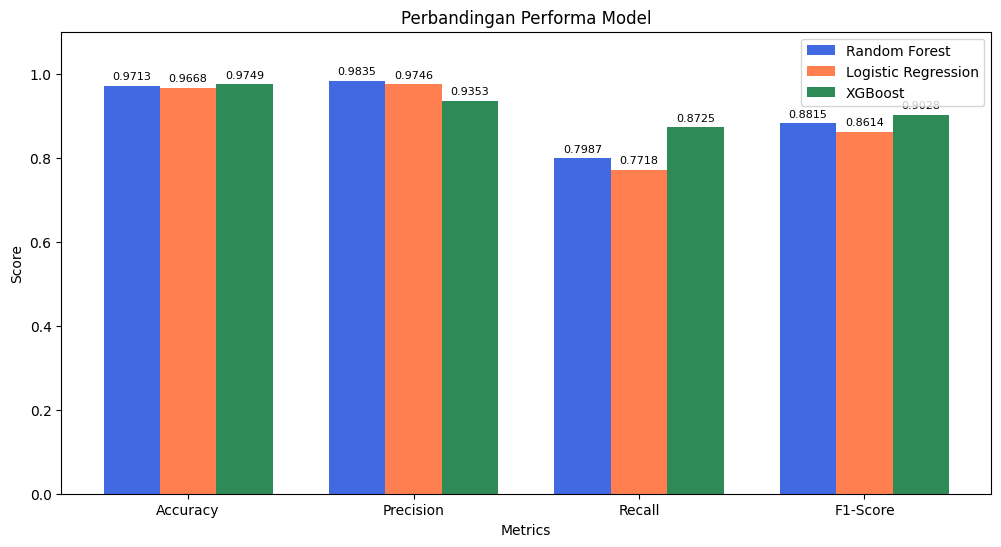

In [20]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores = [rf_acc, rf_prec, rf_rec, rf_f1]
lr_scores = [lr_acc, lr_prec, lr_rec, lr_f1]
xgb_scores = [xgb_acc, xgb_prec, xgb_rec, xgb_f1]

x = range(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))
bars1 = plt.bar([i - width for i in x], rf_scores, width, label='Random Forest', color='royalblue')
bars2 = plt.bar(x, lr_scores, width, label='Logistic Regression', color='coral')
bars3 = plt.bar([i + width for i in x], xgb_scores, width, label='XGBoost', color='seagreen')

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

for bar in bars3:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Perbandingan Performa Model')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend()
plt.show()

# Deep learning menggunakan Word2Vec dan LSTM

In [21]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"Train pad shape: {X_train_pad.shape}")
print(f"Test pad shape: {X_test_pad.shape}")

2026-08-07 12:26:27.352919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786105587.577291      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786105587.638758      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786105588.154263      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786105588.154301      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786105588.154304      24 computation_placer.cc:177] computation placer alr

Train pad shape: (4457, 100)
Test pad shape: (1115, 100)


In [22]:
from gensim.models import Word2Vec

sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, epochs=10)
print(f"Vocab size: {len(w2v_model.wv)}")

vocab_size = min(10000, len(tokenizer.word_index) + 1)
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]
        else:
            embedding_matrix[i] = np.random.normal(0, 0.1, embedding_dim)
            
print(f"Embedding matrix: {embedding_matrix.shape}")

Vocab size: 3225
Embedding matrix: (7288, 100)


In [23]:
model = Sequential([
    Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=True),
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

I0000 00:00:1786105628.005584      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786105628.012000      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       728,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 728,800 (2.78 MB)

 Trainable params: 728,800 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 37s 499ms/step - accuracy: 0.8640 - loss: 0.3649 - val_accuracy: 0.8913 - val_loss: 0.2469
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 485ms/step - accuracy: 0.9414 - loss: 0.1635 - val_accuracy: 0.9596 - val_loss: 0.1369
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 477ms/step - accuracy: 0.9736 - loss: 0.0923 - val_accuracy: 0.9686 - val_loss: 0.0881
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 477ms/step - accuracy: 0.9812 - loss: 0.0631 - val_accuracy: 0.9731 - val_loss: 0.0864
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.9851 - loss: 0.0506 - val_accuracy: 0.9765 - val_loss: 0.0710
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 471ms/step - accuracy: 0.9885 - loss: 0.0351 - val_accuracy: 0.9809 - val_loss: 0.0799
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 465ms/step - accuracy: 0.9905 - loss: 0.0294 - val_accuracy: 0.9776 - val_loss: 0.0947
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 466ms/step - accuracy: 0.9950 - loss: 0.0185 - val_accu

In [24]:
y_pred_lstm = (model.predict(X_test_pad) > 0.5).astype(int)

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_prec = precision_score(y_test, y_pred_lstm)
lstm_rec = recall_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

print("LSTM + Word2Vec")
print("="*50)
print(f"Accuracy: {lstm_acc:.4f}")
print(f"Precision: {lstm_prec:.4f}")
print(f"Recall: {lstm_rec:.4f}")
print(f"F1-Score: {lstm_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lstm))

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step
LSTM + Word2Vec
Accuracy: 0.9830
Precision: 0.9643
Recall: 0.9060
F1-Score: 0.9343

Confusion Matrix:
[[961   5]
 [ 14 135]]


In [25]:
import json

with open('spam_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer disimpan sebagai 'spam_tokenizer.pkl'")

model.save('spam_lstm_word2vec_model.h5')
print("Model LSTM disimpan sebagai 'spam_lstm_word2vec_model.h5'")

lstm_config = {
    'max_len': max_len,
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim
}

with open('spam_lstm_config.json', 'w') as f:
    json.dump(lstm_config, f, indent=4)
print("Konfigurasi LSTM disimpan sebagai 'spam_lstm_config.json'")

Tokenizer disimpan sebagai 'spam_tokenizer.pkl'
Model LSTM disimpan sebagai 'spam_lstm_word2vec_model.h5'
Konfigurasi LSTM disimpan sebagai 'spam_lstm_config.json'


# Comparison Semua Model

In [26]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'XGBoost', 'LSTM + Word2Vec'],
    'Accuracy': [rf_acc, lr_acc, xgb_acc, lstm_acc],
    'Precision': [rf_prec, lr_prec, xgb_prec, lstm_prec],
    'Recall': [rf_rec, lr_rec, xgb_rec, lstm_rec],
    'F1-Score': [rf_f1, lr_f1, xgb_f1, lstm_f1]
})
print(comparison)

                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.971300   0.983471  0.798658  0.881481
1  Logistic Regression  0.966816   0.974576  0.771812  0.861423
2              XGBoost  0.974888   0.935252  0.872483  0.902778
3      LSTM + Word2Vec  0.982960   0.964286  0.906040  0.934256


In [27]:
import os
import shutil

os.makedirs('models/klasik_spam', exist_ok=True)
os.makedirs('models/deep_learning_spam', exist_ok=True)

klasik_files = [
    'spam_random_forest_model.pkl',
    'spam_logistic_regression_model.pkl',
    'spam_xgboost_model.pkl',
    'spam_tfidf_vectorizer.pkl'
]

moved_klasik = 0
for file in klasik_files:
    if os.path.exists(file):
        shutil.move(file, f'models/klasik_spam/{file}')
        print(f"Dipindahkan: {file} → models/klasik_spam/")
        moved_klasik += 1
    else:
        print(f"File tidak ditemukan: {file}")

dl_files = [
    'spam_lstm_word2vec_model.h5',
    'spam_tokenizer.pkl',
    'spam_lstm_config.json'
]

moved_dl = 0
for file in dl_files:
    if os.path.exists(file):
        shutil.move(file, f'models/deep_learning_spam/{file}')
        print(f"Dipindahkan: {file} → models/deep_learning_spam/")
        moved_dl += 1
    else:
        print(f"File not found: {file}")

print(f"\n{moved_klasik} file klasik & {moved_dl} file deep learning SPAM dipindahkan.")

Dipindahkan: spam_random_forest_model.pkl → models/klasik_spam/
Dipindahkan: spam_logistic_regression_model.pkl → models/klasik_spam/
Dipindahkan: spam_xgboost_model.pkl → models/klasik_spam/
Dipindahkan: spam_tfidf_vectorizer.pkl → models/klasik_spam/
Dipindahkan: spam_lstm_word2vec_model.h5 → models/deep_learning_spam/
Dipindahkan: spam_tokenizer.pkl → models/deep_learning_spam/
Dipindahkan: spam_lstm_config.json → models/deep_learning_spam/

4 file klasik & 3 file deep learning SPAM dipindahkan.
